# Analisis dan Segmentasi Developer Stack Overflow 2025

Notebook ini membandingkan **K-Prototypes** dan **DBSCAN** untuk segmentasi developer berdasarkan demografi, pengalaman, kompensasi, teknologi, sistem operasi, dan penggunaan AI agent. Seluruh sel dirancang untuk dijalankan berurutan di **Google Colab**.

> Catatan metodologis: `ConvertedCompYearly` diprioritaskan karena `CompTotal` masih bercampur mata uang. Jika nilai konversi tidak tersedia, notebook memakai `CompTotal` sebagai fallback. Untuk menjaga penggunaan RAM/waktu Colab, eksperimen memakai sampel yang dapat diatur.

In [1]:
!pip -q install kmodes

In [2]:
import os, json, warnings, joblib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from kmodes.kprototypes import KPrototypes
from sklearn.cluster import DBSCAN
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
RANDOM_STATE = 42
pd.set_option('display.max_columns', 100)

## 1. Mount Google Drive dan membaca data

Notebook me-mount Google Drive, membaca dataset dari `MyDrive/project-ml/dataset`, lalu menyimpan hasil ke `MyDrive/project-ml`. Ubah `PROJECT_DIR` jika lokasi folder Anda berbeda.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = Path('/content/drive/MyDrive/Colab Notebooks/PROJECT ML')  # sesuaikan bila folder berbeda
candidate_dirs = [PROJECT_DIR / 'dataset', Path('/content/dataset'), Path('/content')]
DATA_DIR = next((p for p in candidate_dirs if (p / 'results.csv').exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError(
        f'results.csv tidak ditemukan. Pastikan file berada di {PROJECT_DIR / "dataset"}.'
    )

results_path = DATA_DIR / 'results.csv'
schema_path = DATA_DIR / 'schema.csv'
df_raw = pd.read_csv(results_path, low_memory=False, encoding='utf-8-sig')
schema = pd.read_csv(schema_path, encoding='utf-8-sig') if schema_path.exists() else None
print(f'Data: {results_path} | bentuk: {df_raw.shape}')
print(f'Schema: {schema_path if schema is not None else "tidak ditemukan (opsional)"}')
display(df_raw.head(3))

Mounted at /content/drive
Data: /content/drive/MyDrive/Colab Notebooks/PROJECT ML/dataset/results.csv | bentuk: (49191, 172)
Schema: /content/drive/MyDrive/Colab Notebooks/PROJECT ML/dataset/schema.csv


,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,AILearnHow,YearsCode,DevType,OrgSize,ICorPM,RemoteWork,PurchaseInfluence,TechEndorseIntro,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,TechEndorse_8,TechEndorse_9,TechEndorse_13,TechEndorse_13_TEXT,TechOppose_1,TechOppose_2,TechOppose_3,TechOppose_5,TechOppose_7,TechOppose_9,TechOppose_11,TechOppose_13,TechOppose_16,TechOppose_15,TechOppose_15_TEXT,Industry,JobSatPoints_1,JobSatPoints_2,JobSatPoints_3,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,...,SO_Actions_1,SO_Actions_16,SO_Actions_3,SO_Actions_4,SO_Actions_5,SO_Actions_6,SO_Actions_9,SO_Actions_7,SO_Actions_10,SO_Actions_15,SO_Actions_15_TEXT,SOComm,SOFriction,AISelect,AISent,AIAcc,AIComplex,AIToolCurrently partially AI,AIToolDon't plan to use AI for this task,AIToolPlan to partially use AI,AIToolPlan to mostly use AI,AIToolCurrently mostly AI,AIFrustration,AIExplain,AIAgents,AIAgentChange,AIAgent_Uses,AgentUsesGeneral,AIAgentImpactSomewhat agree,AIAgentImpactNeutral,AIAgentImpactSomewhat disagree,AIAgentImpactStrongly agree,AIAgentImpactStrongly disagree,AIAgentChallengesNeutral,AIAgentChallengesSomewhat disagree,AIAgentChallengesStrongly agree,AIAgentChallengesSomewhat agree,AIAgentChallengesStrongly disagree,AIAgentKnowledge,AIAgentKnowWrite,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,14.0,"Developer, mobile",20 to 99 employees,People manager,Remote,"Yes, I influenced the purchase of a substantia...",Work,10.0,7.0,9.0,6.0,3.0,11.0,12.0,1.0,8.0,14.0,NaN,15.0,7.0,8.0,12.0,11.0,1.0,6.0,13.0,3.0,16.0,NaN,Fintech,3.0,1.0,4.0,9.0,5.0,10.0,12.0,11.0,2.0,...,1.0,NaN,6.0,2.0,3.0,7.0,8.0,9.0,11.0,15.0,NaN,Neutral,"Rarely, almost never","Yes, I use AI tools monthly or infrequently",Indifferent,Neither trust nor distrust,Bad at handling complex tasks,Learning about a codebase;Writing code;Search ...,Project planning;Deployment and monitoring;Lea...,Documenting code;Debugging or fixing code;Test...,NaN,NaN,"AI solutions that are almost right, but not quite",No,"Yes, I use AI agents at work monthly or infreq...",Not at all or minimally,Software engineering,NaN,AI agents have increased my productivity.;AI a...,AI agents have helped me automate repetitive t...,NaN,NaN,NaN,I am concerned about the accuracy of the infor...,Integrating AI agents with my existing tools a...,The cost of using certain AI agent platforms i...,NaN,NaN,NaN,NaN,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,10.0,"Developer, back-end",500 to 999 employees,Individual contributor,"Hybrid (some in-person, leans heavy to flexibi...",No,Personal Project,13.0,1.0,2.0,9.0,4.0,3.0,12.0,5.0,7.0,14.0,NaN,14.0,1.0,13.0,10.0,9.0,3.0,4.0,2.0,5.0,15.0,NaN,Retail and Consumer Services,10.0,8.0,3.0,9.0,12.0,1.0,6.0,2.0,11.0,...,6.0,NaN,5.0,8.0,2.0,4.0,9.0,10.0,11.0,15.0,NaN,"Yes, somewhat",About half of the time,"Yes, I use AI tools weekly",Indifferent,Neither trust nor distrust,Bad at handling complex tasks,Learning new concepts or technologies,Learning about a codebase;Project planning;Com...,Writing code;Documen

## 2. Seleksi, pembersihan, dan ekstraksi fitur

Kolom teknologi pada data survei bersifat multi-jawaban dan dipisahkan tanda titik koma. Setiap jawaban dipecah dengan `.str.split(';')`, lalu teknologi yang paling sering muncul dijadikan fitur biner. Pendekatan ini menjaga makna masing-masing teknologi tanpa menciptakan puluhan ribu kombinasi kategori.

In [4]:
COLUMN_MAP = {
    'Language': 'LanguageHaveWorkedWith',
    'Webframe': 'WebframeHaveWorkedWith',
    'OpSys': 'OpSysProfessional use',
    'Database': 'DatabaseHaveWorkedWith',
    'AIAgents': 'AIAgents',
}
required = ['ResponseId', 'Age', 'YearsCode', 'CompTotal', 'ConvertedCompYearly', *COLUMN_MAP.values()]
missing = [c for c in required if c not in df_raw.columns]
if missing:
    raise KeyError(f'Kolom yang dibutuhkan tidak ada: {missing}')

df = df_raw[required].copy()
display(df.isna().mean().sort_values(ascending=False).to_frame('proporsi_kosong'))

,proporsi_kosong
WebframeHaveWorkedWith,0.532597
ConvertedCompYearly,0.513183
CompTotal,0.494501
DatabaseHaveWorkedWith,0.480596
OpSysProfessional use,0.412840
LanguageHaveWorkedWith,0.356163
AIAgents,0.351121
YearsCode,0.125003
Age,0.000000
ResponseId,0.000000


In [5]:
def age_to_numeric(value):
    mapping = {
        'Under 18 years old': 16, '18-24 years old': 21, '25-34 years old': 29.5,
        '35-44 years old': 39.5, '45-54 years old': 49.5,
        '55-64 years old': 59.5, '65 years or older': 70,
        'Prefer not to say': np.nan,
    }
    return mapping.get(value, np.nan)

def years_to_numeric(value):
    if pd.isna(value): return np.nan
    text = str(value).strip()
    if text == 'Less than 1 year': return 0.5
    if text == 'More than 50 years': return 51.0
    return pd.to_numeric(text, errors='coerce')

df['AgeNumeric'] = df['Age'].map(age_to_numeric)
df['YearsCodeNumeric'] = df['YearsCode'].map(years_to_numeric)
converted = pd.to_numeric(df['ConvertedCompYearly'], errors='coerce')
raw_comp = pd.to_numeric(df['CompTotal'], errors='coerce')
df['Compensation'] = converted.fillna(raw_comp)

# Winsorization mengurangi dominasi outlier, lalu log1p memperkecil kemencengan distribusi.
for col in ['AgeNumeric', 'YearsCodeNumeric', 'Compensation']:
    df[col] = df[col].fillna(df[col].median())
low, high = df['Compensation'].quantile([0.01, 0.99])
df['Compensation'] = df['Compensation'].clip(low, high)
df['LogCompensation'] = np.log1p(df['Compensation'].clip(lower=0))

df[['AgeNumeric', 'YearsCodeNumeric', 'Compensation']].describe().round(2)

,AgeNumeric,YearsCodeNumeric,Compensation
count,49191.00,49191.00,49191.00
mean,35.53,16.25,79545.49
std,11.60,11.06,52090.99
min,21.00,1.00,0.00
25%,29.50,8.00,71698.00
50%,29.50,14.00,72509.00
75%,39.50,21.00,73292.00
max,70.00,100.00,330000.00


In [6]:
TOP_N_PER_TECH = 10
tech_flag_columns = []
tech_name_lookup = {}

for short_name, source_col in COLUMN_MAP.items():
    # Imputasi kategori dengan modus sebelum pemecahan multi-jawaban.
    mode = df[source_col].mode(dropna=True)
    fill_value = mode.iloc[0] if not mode.empty else 'Unknown'
    split_values = df[source_col].fillna(fill_value).astype(str).str.split(';')
    df[f'{short_name}Count'] = split_values.str.len().astype(float)
    top_values = split_values.explode().str.strip().value_counts().head(TOP_N_PER_TECH).index

    for i, technology in enumerate(top_values):
        safe_col = f'{short_name}__{i:02d}'
        df[safe_col] = split_values.apply(lambda items, t=technology: int(t in [x.strip() for x in items]))
        tech_flag_columns.append(safe_col)
        tech_name_lookup[safe_col] = f'{short_name}: {technology}'

print(f'Jumlah fitur teknologi biner: {len(tech_flag_columns)}')
display(pd.Series(tech_name_lookup, name='arti_fitur').to_frame().head(20))

Jumlah fitur teknologi biner: 46


,arti_fitur
Language__00,Language: JavaScript
Language__01,Language: HTML/CSS
Language__02,Language: TypeScript
Language__03,Language: SQL
Language__04,Language: Python
Language__05,Language: Bash/Shell (all shells)
Language__06,Language: Java
Language__07,Language: C#
Language__08,Language: C++
Language__09,Language: PowerShell


## 3. Dataset A (K-Prototypes) dan Dataset B (DBSCAN)

Dataset A mempertahankan fitur numerik dan fitur teknologi sebagai kategori `Ya/Tidak`. Dataset B mengubah kategori dengan one-hot encoding dan menstandarkan fitur numerik. Sampel dipakai karena DBSCAN dapat membutuhkan memori kuadratik pada kondisi terburuk.

In [7]:
MAX_ROWS = 6000  # naikkan jika runtime/RAM Colab mencukupi
model_df = df.sample(n=min(MAX_ROWS, len(df)), random_state=RANDOM_STATE).reset_index(drop=True)

numeric_features = [
    'AgeNumeric', 'YearsCodeNumeric', 'LogCompensation',
    *[f'{name}Count' for name in COLUMN_MAP],
]
categorical_features = tech_flag_columns

# Dataset A: numerik terstandar + kategori string untuk K-Prototypes.
# Standardisasi mencegah usia atau kompensasi mendominasi jarak numerik.
kproto_scaler = StandardScaler()
X_kproto_df = model_df[numeric_features + categorical_features].copy()
X_kproto_df[numeric_features] = kproto_scaler.fit_transform(X_kproto_df[numeric_features])
X_kproto_df[categorical_features] = X_kproto_df[categorical_features].astype(str)
categorical_indices = list(range(len(numeric_features), X_kproto_df.shape[1]))
X_kproto = X_kproto_df.to_numpy(dtype=object)

# Dataset B: scaler numerik + one-hot kategori untuk DBSCAN.
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
])
X_db = preprocessor.fit_transform(model_df[numeric_features + categorical_features]).astype(np.float32)

print('Dataset A:', X_kproto.shape, '| indeks kategorikal:', categorical_indices[:3], '...')
print('Dataset B:', X_db.shape, '| seluruh fitur numerik dan sudah ditransformasi')

Dataset A: (6000, 54) | indeks kategorikal: [8, 9, 10] ...
Dataset B: (6000, 100) | seluruh fitur numerik dan sudah ditransformasi


## 4. Eksperimen K-Prototypes

`cost` dipakai sebagai kurva elbow. Silhouette dihitung pada representasi numerik Dataset B agar jarak dapat dihitung dan hasil kedua algoritma dapat dibandingkan pada ruang fitur yang sama.

K=3: cost=44,602, silhouette=0.1723
K=4: cost=40,595, silhouette=0.1774
K=5: cost=37,994, silhouette=0.1850
K=6: cost=36,334, silhouette=0.1863
K terbaik berdasarkan silhouette: 6


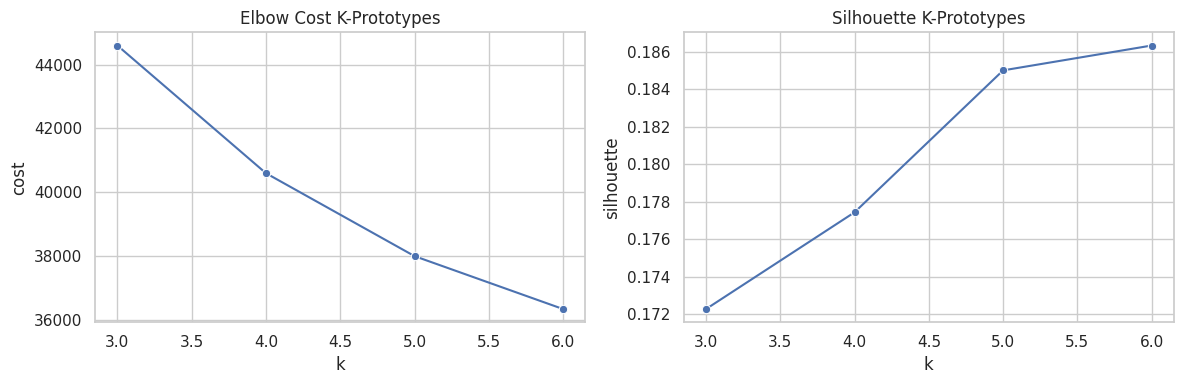

In [8]:
k_results, k_models = [], {}
for k in range(3, 7):
    model = KPrototypes(n_clusters=k, init='Cao', n_init=3, max_iter=30, random_state=RANDOM_STATE, verbose=0)
    labels = model.fit_predict(X_kproto, categorical=categorical_indices)
    sil = silhouette_score(X_db, labels, sample_size=min(3000, len(labels)), random_state=RANDOM_STATE)
    k_models[k] = (model, labels)
    k_results.append({'k': k, 'cost': model.cost_, 'silhouette': sil})
    print(f'K={k}: cost={model.cost_:,.0f}, silhouette={sil:.4f}')

k_results = pd.DataFrame(k_results)
best_k = int(k_results.loc[k_results['silhouette'].idxmax(), 'k'])
best_kproto, labels_kproto = k_models[best_k]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.lineplot(data=k_results, x='k', y='cost', marker='o', ax=axes[0])
sns.lineplot(data=k_results, x='k', y='silhouette', marker='o', ax=axes[1])
axes[0].set_title('Elbow Cost K-Prototypes')
axes[1].set_title('Silhouette K-Prototypes')
plt.tight_layout()
print(f'K terbaik berdasarkan silhouette: {best_k}')

## 5. Tuning DBSCAN

Kandidat `eps` diambil otomatis dari kuantil jarak tetangga ke-`min_samples`. Pemilihan mempertimbangkan silhouette sekaligus cakupan data non-noise agar model tidak menang hanya karena membentuk klaster yang sangat kecil. Label `-1` adalah anomali/noise.

In [9]:
MIN_SAMPLES_OPTIONS = [5, 10, 15]
EPS_QUANTILES = [0.70, 0.80, 0.90, 0.95]
db_results, db_models = [], {}

for min_samples in MIN_SAMPLES_OPTIONS:
    nn = NearestNeighbors(n_neighbors=min_samples, n_jobs=-1).fit(X_db)
    distances, _ = nn.kneighbors(X_db)
    kth_dist = np.sort(distances[:, -1])
    eps_candidates = np.unique(np.quantile(kth_dist, EPS_QUANTILES).round(4))

    for eps in eps_candidates:
        model = DBSCAN(eps=float(eps), min_samples=min_samples, n_jobs=-1)
        labels = model.fit_predict(X_db)
        mask = labels != -1
        unique_clusters = np.unique(labels[mask])
        coverage = float(mask.mean())
        sil = np.nan
        if len(unique_clusters) >= 2 and mask.sum() > len(unique_clusters):
            sil = silhouette_score(
                X_db[mask], labels[mask], sample_size=min(3000, mask.sum()), random_state=RANDOM_STATE
            )
        objective = sil * coverage if np.isfinite(sil) else -1.0
        row = {'eps': float(eps), 'min_samples': min_samples, 'clusters': len(unique_clusters),
               'noise_pct': 100 * (1 - coverage), 'coverage': coverage,
               'silhouette_non_noise': sil, 'objective': objective}
        db_results.append(row)
        db_models[(float(eps), min_samples)] = (model, labels)

db_results = pd.DataFrame(db_results).sort_values('objective', ascending=False).reset_index(drop=True)
valid = db_results.query('clusters >= 2 and clusters <= 15 and coverage >= 0.50')
best_row = valid.iloc[0] if len(valid) else db_results.iloc[0]
best_eps, best_min_samples = float(best_row['eps']), int(best_row['min_samples'])
best_dbscan, labels_dbscan = db_models[(best_eps, best_min_samples)]
display(db_results.round(4))
print(f'DBSCAN terpilih: eps={best_eps}, min_samples={best_min_samples}, '
      f'cluster={int(best_row["clusters"])}, noise={best_row["noise_pct"]:.1f}%')

,eps,min_samples,clusters,noise_pct,coverage,silhouette_non_noise,objective
0,4.6096,5,3,5.5833,0.9442,0.3344,0.3157
1,3.8102,5,1,21.3000,0.7870,NaN,-1.0000
2,4.1477,5,1,13.1500,0.8685,NaN,-1.0000
3,4.9505,5,1,2.4500,0.9755,NaN,-1.0000
4,4.0177,10,1,17.7167,0.8228,NaN,-1.0000
5,4.3472,10,1,10.3333,0.8967,NaN,-1.0000
6,4.8074,10,1,4.1333,0.9587,NaN,-1.0000
7,5.1608,10,1,1.7500,0.9825,NaN,-1.0000
8,4.1336,15,1,15.9000,0.8410,NaN,-1.0000
9,4.4609,15,1,8.9000,0.9110,NaN,-1.0000


DBSCAN terpilih: eps=4.6096, min_samples=5, cluster=3, noise=5.6%


## 6. Evaluasi komparatif dan visualisasi PCA

,Model,Silhouette,Jumlah cluster,Noise (%)
0,K-Prototypes (K=6),0.1863,6,0.0000
1,"DBSCAN (eps=4.6096, min=5)",0.3344,3,5.5833


Variansi yang dijelaskan 2 PC: 32.91%


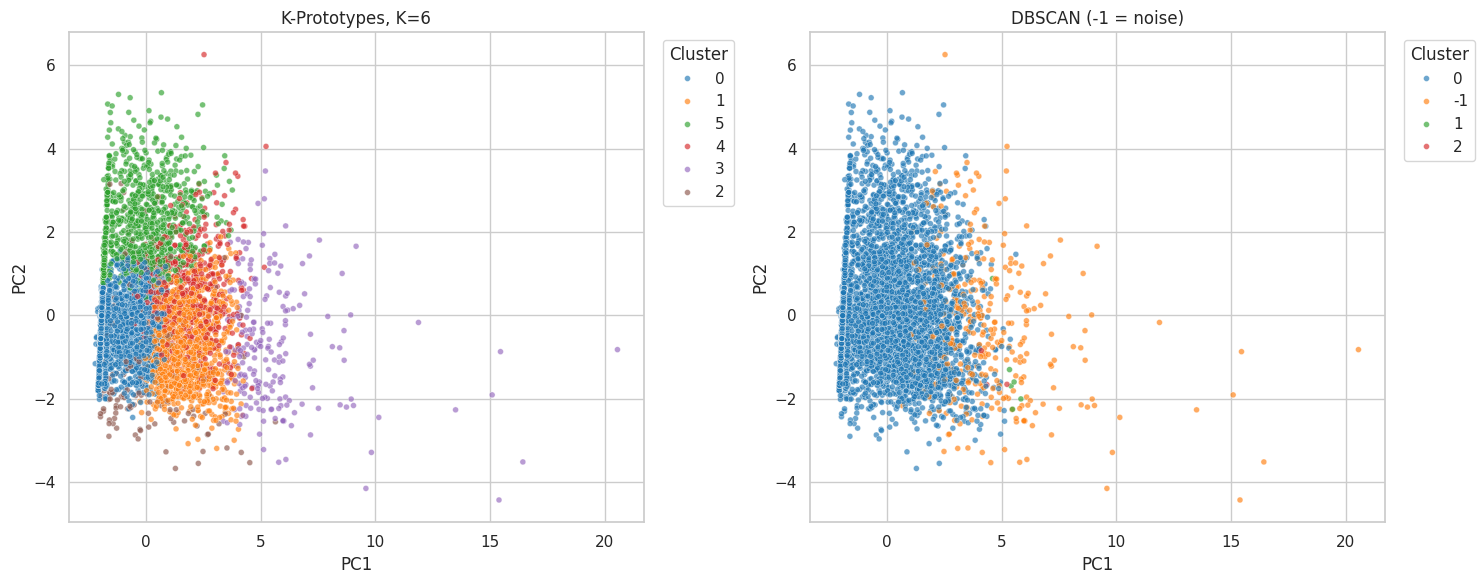

In [10]:
sil_k = silhouette_score(X_db, labels_kproto, sample_size=min(3000, len(labels_kproto)), random_state=RANDOM_STATE)
db_mask = labels_dbscan != -1
db_clusters = np.unique(labels_dbscan[db_mask])
sil_db = (silhouette_score(X_db[db_mask], labels_dbscan[db_mask],
                           sample_size=min(3000, db_mask.sum()), random_state=RANDOM_STATE)
          if len(db_clusters) >= 2 else np.nan)
comparison = pd.DataFrame([
    {'Model': f'K-Prototypes (K={best_k})', 'Silhouette': sil_k,
     'Jumlah cluster': len(np.unique(labels_kproto)), 'Noise (%)': 0.0},
    {'Model': f'DBSCAN (eps={best_eps:g}, min={best_min_samples})', 'Silhouette': sil_db,
     'Jumlah cluster': len(db_clusters), 'Noise (%)': 100 * (~db_mask).mean()},
])
display(comparison.round(4))

pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_db)
plot_df = pd.DataFrame({'PC1': coords[:, 0], 'PC2': coords[:, 1],
                            'K-Prototypes': labels_kproto.astype(str),
                            'DBSCAN': labels_dbscan.astype(str)})
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='K-Prototypes', s=18, alpha=.65, ax=axes[0], palette='tab10')
sns.scatterplot(data=plot_df, x='PC1', y='PC2', hue='DBSCAN', s=18, alpha=.65, ax=axes[1], palette='tab10')
axes[0].set_title(f'K-Prototypes, K={best_k}')
axes[1].set_title('DBSCAN (-1 = noise)')
for ax in axes: ax.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
print(f'Variansi yang dijelaskan 2 PC: {pca.explained_variance_ratio_.sum():.2%}')

## 7. Profil klaster

Tabel berikut menampilkan ukuran klaster, median karakteristik numerik, serta lima teknologi yang paling umum. Profil DBSCAN menyertakan cluster `-1` supaya karakter anomali juga dapat diperiksa.

In [14]:
profile_base = model_df[['ResponseId', 'AgeNumeric', 'YearsCodeNumeric', 'Compensation', *tech_flag_columns]].copy()
profile_base['Cluster_KPrototypes'] = labels_kproto
profile_base['Cluster_DBSCAN'] = labels_dbscan

def cluster_profile(data, label_col):
    numeric = data.groupby(label_col).agg(
        Jumlah=('ResponseId', 'size'),
        Median_Usia=('AgeNumeric', 'median'),
        Median_Tahun_Coding=('YearsCodeNumeric', 'median'),
        Median_Kompensasi=('Compensation', 'median'),
    )
    rows = []
    for cluster, group in data.groupby(label_col):
        rates = group[tech_flag_columns].mean().sort_values(ascending=False).head(5)
        rows.append((cluster, '; '.join(f'{tech_name_lookup[c]} ({v:.0%})' for c, v in rates.items())))
    tops = pd.DataFrame(rows, columns=[label_col, 'Top_5_Teknologi']).set_index(label_col)
    return numeric.join(tops).round(2)

print('PROFIL K-PROTOTYPES')
display(cluster_profile(profile_base, 'Cluster_KPrototypes'))
print('PROFIL DBSCAN')
display(cluster_profile(profile_base, 'Cluster_DBSCAN'))

PROFIL K-PROTOTYPES


,Jumlah,Median_Usia,Median_Tahun_Coding,Median_Kompensasi,Top_5_Teknologi
Cluster_KPrototypes,,,,,
0,2893,29.5,13.0,72509.0,Webframe: React (87%); Database: PostgreSQL (8...
1,1143,29.5,12.0,72509.0,Language: JavaScript (90%); Language: HTML/CSS...
2,157,29.5,8.0,0.0,Database: PostgreSQL (76%); Language: JavaScri...
3,216,29.5,15.0,72509.0,Language: JavaScript (96%); Language: HTML/CSS...
4,594,39.5,17.0,72509.0,Language: Python (70%); OpSys: Windows (69%); ...
5,997,49.5,30.0,72509.0,OpSys: Windows (70%); Webframe: React (69%); D...


PROFIL DBSCAN


,Jumlah,Median_Usia,Median_Tahun_Coding,Median_Kompensasi,Top_5_Teknologi
Cluster_DBSCAN,,,,,
-1,335,39.5,15.0,72509.0,Language: JavaScript (87%); Language: Python (...
0,5656,29.5,14.0,72509.0,Database: PostgreSQL (78%); Language: JavaScri...
1,6,29.5,12.5,72509.0,Language: JavaScript (100%); Language: HTML/CS...
2,3,21.0,11.0,81210.0,Language: JavaScript (100%); Language: HTML/CS...


## 8. Kesimpulan otomatis

Interpretasikan silhouette bersama ukuran klaster, persentase noise, plot PCA, dan kegunaan segmen. Silhouette tinggi tidak otomatis berarti segmentasi paling berguna secara substantif.

In [12]:
if np.isfinite(sil_db) and sil_db > sil_k:
    winner = 'DBSCAN memiliki silhouette non-noise lebih tinggi.'
else:
    winner = 'K-Prototypes memiliki silhouette lebih tinggi atau DBSCAN tidak membentuk minimal dua cluster valid.'

print('RINGKASAN HASIL')
print(f'- K-Prototypes terbaik: K={best_k}, silhouette={sil_k:.4f}.')
print(f'- DBSCAN terbaik: eps={best_eps:g}, min_samples={best_min_samples}, '
      f'silhouette non-noise={sil_db if np.isfinite(sil_db) else float("nan"):.4f}, noise={(~db_mask).mean():.1%}.')
print(f'- {winner}')
print('- Gunakan tabel profil untuk memberi nama bisnis pada setiap segmen, misalnya ekosistem web, backend/cloud, atau pengguna AI agent.')

RINGKASAN HASIL
- K-Prototypes terbaik: K=6, silhouette=0.1863.
- DBSCAN terbaik: eps=4.6096, min_samples=5, silhouette non-noise=0.3344, noise=5.6%.
- DBSCAN memiliki silhouette non-noise lebih tinggi.
- Gunakan tabel profil untuk memberi nama bisnis pada setiap segmen, misalnya ekosistem web, backend/cloud, atau pengguna AI agent.


## 9. Ekspor hasil dan model (opsional)

Semua file hasil disimpan langsung ke `PROJECT_DIR`, yaitu folder proyek yang sama dengan notebook dan subfolder `dataset`. CSV hasil hanya berisi responden pada sampel pemodelan.

In [13]:
OUTPUT_DIR = PROJECT_DIR
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

export_df = model_df[['ResponseId', 'Age', 'YearsCode', 'Compensation']].copy()
export_df['Cluster_KPrototypes'] = labels_kproto
export_df['Cluster_DBSCAN'] = labels_dbscan
export_df.to_csv(OUTPUT_DIR / 'hasil_segmentasi.csv', index=False)
joblib.dump(best_kproto, OUTPUT_DIR / 'model_kprototypes.pkl')
joblib.dump(kproto_scaler, OUTPUT_DIR / 'scaler_kprototypes.pkl')
joblib.dump(best_dbscan, OUTPUT_DIR / 'model_dbscan.pkl')
joblib.dump(preprocessor, OUTPUT_DIR / 'preprocessor_dbscan.pkl')
joblib.dump(pca, OUTPUT_DIR / 'pca_visualisasi.pkl')

metadata = {
    'best_k': best_k, 'dbscan_eps': best_eps, 'dbscan_min_samples': best_min_samples,
    'numeric_features': numeric_features, 'categorical_features': categorical_features,
    'tech_name_lookup': tech_name_lookup, 'random_state': RANDOM_STATE,
}
with open(OUTPUT_DIR / 'metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)
print(f'Semua output tersimpan di: {OUTPUT_DIR}')
print(sorted(p.name for p in OUTPUT_DIR.iterdir()))

Semua output tersimpan di: /content/drive/MyDrive/Colab Notebooks/PROJECT ML
['analisis_segmentasi_stackoverflow_2025.ipynb', 'dataset', 'hasil_segmentasi.csv', 'metadata.json', 'model_dbscan.pkl', 'model_kprototypes.pkl', 'pca_visualisasi.pkl', 'preprocessor_dbscan.pkl', 'scaler_kprototypes.pkl']
